## Approche hybride

Ce notebook implémente et évalue l'approche hybride fréquentielle : on entraîne une architecture multi-branches fusionnant trois ResNet18 (images originales, passe-haut et passe-bas), puis on compare ses performances aux trois modèles individuels et on génère les visualisations barplot et t-SNE du rapport.

#### Sommaire

1. [Architecture multi-branches](#1-approche-multi-branches)
2. [Visualisations](#2-visualisations)
   - [Barplot par style](#51-barplot-accuracy-par-style)
   - [Visualisations t-SNE](#52-visualisations-t-sne)




> **Note importante** : Les modèles ResNet18 original, haute fréquence et basse fréquence ont été entraînés séparément dans le notebook `4_RV_DL_BaselineResnet`. Leurs poids sont sauvegardés sur Drive :
> - `resnet18_baseline_02.pt` — ResNet18 entraîné sur images originales
> - `resnet18_baseline_HF.pt` — ResNet18 entraîné sur images haute fréquence
> - `resnet18_baseline_BF.pt` — ResNet18 entraîné sur images basse fréquence

Les poids du modèle multi-branches sont sauvegardés dans ce notebook sous `multibranch_best.pth`.



#### Imports de base

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import sys
from pathlib import Path

# Pour que notre archi fonctionne avec google colab

!git clone https://github.com/julietteabalain-cloud/Reconnaissance-de-mouvement-artistique.git
!cd /content/Reconnaissance-de-mouvement-artistique && git pull
%cd /content/Reconnaissance-de-mouvement-artistique


Cloning into 'Reconnaissance-de-mouvement-artistique'...
remote: Enumerating objects: 539, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 539 (delta 42), reused 50 (delta 23), pack-reused 469 (from 1)
Receiving objects: 100% (539/539), 94.69 MiB | 33.92 MiB/s, done.
Resolving deltas: 100% (349/349), done.
Already up to date.
/content/Reconnaissance-de-mouvement-artistique


In [ ]:
from pathlib import Path
REPO_NAME = "Reconnaissance-de-mouvement-artistique"
PROJECT_ROOT = Path(f"/content/{REPO_NAME}")
sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.dataset_dl import ArtDataset
from src.train import train_model, train_one_epoch, validate_one_epoch

from src.dataset import load_df_train_test_val, load_df
from src.preprocessing import clean_dataset

from src.models import get_model
from src.evaluate import *
from src.utils import set_seed

#Fixer l'initialisation aléatoire pour la reproductibilité
set_seed(42)

#pour avoir acces au GPU si dispo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/DeepLearning/WikiArt_Subset")

df_test, df_train, df_val = load_df_train_test_val(DATA_ROOT)
df = load_df(DATA_ROOT)

df, df_train, df_val, df_test = clean_dataset(df, df_train, df_val, df_test)

/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

## 0. Préparation des hyper-paramètres et du dataset

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

## 1. Approche multi-branches

In [ ]:
from src.dataset_dl import ArtDatasetMultiBranch
from src.models import get_multibranch_resnet18
from src.train import train_model_multibranch
from src.frequency_analysis import LowFrequencyTransform, HighFrequencyTransform

In [ ]:
high_freq_transform = transforms.Compose([
    HighFrequencyTransform(kernel_size=9, sigma=2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

low_freq_transform = transforms.Compose([
    LowFrequencyTransform(kernel_size=9, sigma=2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:

# Datasets
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset_mb = ArtDatasetMultiBranch(
    df_train, IMAGE_ROOT_TRAIN,
    transform_orig=transform_val,
    transform_hf=high_freq_transform,
    transform_lf=low_freq_transform
)
val_dataset_mb = ArtDatasetMultiBranch(
    df_val, IMAGE_ROOT_VAL,
    transform_orig=transform_val,
    transform_hf=high_freq_transform,
    transform_lf=low_freq_transform
)

train_loader_mb = DataLoader(train_dataset_mb, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_mb   = DataLoader(val_dataset_mb,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
#Modèle
num_classes = df_train["style_encoded"].nunique()
model_mb    = get_multibranch_resnet18(num_classes=num_classes, device=device, drop=True)
criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_mb = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_mb.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler_mb = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mb, mode='min', factor=0.3, patience=2
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


Paramètres entraînables : 35,351 / 33,564,887 (0.1%)


In [ ]:
# Entraînement
history_mb = train_model_multibranch(
    model_mb,
    train_loader_mb,
    val_loader_mb,
    criterion,
    optimizer_mb,
    device,
    num_epochs=5,
    early_stopping=EarlyStopping(patience=3),
    scheduler=scheduler_mb
)

torch.save(model_mb.state_dict(), "modele_multibranches.pth")


Epoch 1/5


Train Loss: 2.6076 | Train Acc: 0.2768 | Val Loss: 2.3642 | Val Acc: 0.3591
Meilleur modèle sauvegardé
LR: 1.00e-03

Epoch 2/5


Train Loss: 2.1928 | Train Acc: 0.4108 | Val Loss: 2.2884 | Val Acc: 0.3999
Meilleur modèle sauvegardé
LR: 1.00e-03

Epoch 3/5


Train Loss: 2.1051 | Train Acc: 0.4489 | Val Loss: 2.1677 | Val Acc: 0.4370
Meilleur modèle sauvegardé
LR: 1.00e-03

Epoch 4/5


Train Loss: 2.0498 | Train Acc: 0.4669 | Val Loss: 2.1868 | Val Acc: 0.4326
LR: 1.00e-03

Epoch 5/5


Train Loss: 2.0222 | Train Acc: 0.4762 | Val Loss: 2.1670 | Val Acc: 0.4275
Meilleur modèle sauvegardé
LR: 1.00e-03
Meilleur modèle restauré (val_loss=2.1670)


## 2. Visualisations

In [ ]:
from src.evaluate import (
    evaluate_model, evaluate_model_multibranch,
    accuracy_per_class, accuracy_per_class_fast, accuracy_per_class_multibranch,
    plot_style_accuracy_comparison,
    extract_embeddings, extract_embeddings_multibranch,
    plot_tsne
)
from src.models import get_resnet18

In [ ]:

transform_std = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_dataset_orig = ArtDataset(df_test, IMAGE_ROOT_TEST, transform=transform_std)
test_dataset_hf   = ArtDataset(df_test, IMAGE_ROOT_TEST, transform=high_freq_transform)
test_dataset_lf   = ArtDataset(df_test, IMAGE_ROOT_TEST, transform=low_freq_transform)
test_dataset_mb   = ArtDatasetMultiBranch(
    df_test, IMAGE_ROOT_TEST,
    transform_orig=transform_std,
    transform_hf=high_freq_transform,
    transform_lf=low_freq_transform
)

test_loader_orig = DataLoader(test_dataset_orig, batch_size=32, shuffle=False, num_workers=2)
test_loader_hf   = DataLoader(test_dataset_hf,   batch_size=32, shuffle=False, num_workers=2)
test_loader_lf   = DataLoader(test_dataset_lf,   batch_size=32, shuffle=False, num_workers=2)
test_loader_mb   = DataLoader(test_dataset_mb,   batch_size=32, shuffle=False, num_workers=2)


Chargement des modèles déjà entrainés

In [ ]:

num_classes = df_test["style_encoded"].nunique()

model_orig = get_resnet18(num_classes=num_classes, device=device, drop=True)
checkpoint = torch.load("/content/drive/MyDrive/DeepLearning/resnet18_baseline_02.pt", weights_only=True)
model_orig.load_state_dict(checkpoint["model_state_dict"])
model_orig = model_orig.to(device)
print("ResNet18 original")

model_hf = get_resnet18(num_classes=num_classes, device=device, drop=True)
checkpoint = torch.load("/content/drive/MyDrive/DeepLearning/resnet18_baseline_HF.pt", weights_only=True)
model_hf.load_state_dict(checkpoint["model_state_dict"])
model_hf = model_hf.to(device)
print("ResNet18 haute fréquence")

model_lf = get_resnet18(num_classes=num_classes, device=device, drop=True)
checkpoint = torch.load("/content/drive/MyDrive/DeepLearning/resnet18_baseline_BF.pt", weights_only=True)
model_lf.load_state_dict(checkpoint["model_state_dict"])
model_lf = model_lf.to(device)
print("ResNet18 basse fréquence")

model_mb = get_multibranch_resnet18(num_classes=num_classes, device=device, drop=True)
model_mb.load_state_dict(torch.load("/content/drive/MyDrive/DeepLearning/multibranch_best.pth", weights_only=True))
model_mb = model_mb.to(device)
print("Multi-branches")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


ResNet18 original
ResNet18 haute fréquence
ResNet18 basse fréquence
Paramètres entraînables : 35,351 / 33,564,887 (0.1%)
Multi-branches


Calcul des accuracy test

In [ ]:
acc_orig, _, _ = evaluate_model(model_orig, test_loader_orig, device)
acc_hf,   _, _ = evaluate_model(model_hf,   test_loader_hf,   device)
acc_lf,   _, _ = evaluate_model(model_lf,   test_loader_lf,   device)
acc_mb,   _, _ = evaluate_model_multibranch(model_mb, test_loader_mb, device)

print(f"\n{'Modèle':<25} {'Accuracy test':>13}")
print("-" * 40)
print(f"{'Original':<25} {acc_orig:>13.3f}")
print(f"{'Haute fréquence':<25} {acc_hf:>13.3f}")
print(f"{'Basse fréquence':<25} {acc_lf:>13.3f}")
print(f"{'Multi-branches':<25} {acc_mb:>13.3f}")


Modèle                    Accuracy test
----------------------------------------
Original                          0.401
Haute fréquence                   0.306
Basse fréquence                   0.401
Multi-branches                    0.418


#### Barplot horizontal des accuracy par style

In [ ]:
class_names = sorted(df_test["style_name"].unique())

per_class_orig = accuracy_per_class_fast(model_orig, test_loader_orig, device, class_names)
print(f"Original : {per_class_orig.mean():.3f}")
per_class_hf   = accuracy_per_class_fast(model_hf,   test_loader_hf,   device, class_names)
print(f"Haute fréquence : {per_class_hf.mean():.3f}")
per_class_lf   = accuracy_per_class_fast(model_lf,   test_loader_lf,   device, class_names)
print(f"Basse fréquence : {per_class_lf.mean():.3f}")
per_class_mb   = accuracy_per_class_multibranch(model_mb, test_loader_mb, device, class_names)
print(f"Multi-branches : {per_class_mb.mean():.3f}")


Original : 0.408
Haute fréquence : 0.314
Basse fréquence : 0.405
Multi-branches : 0.422


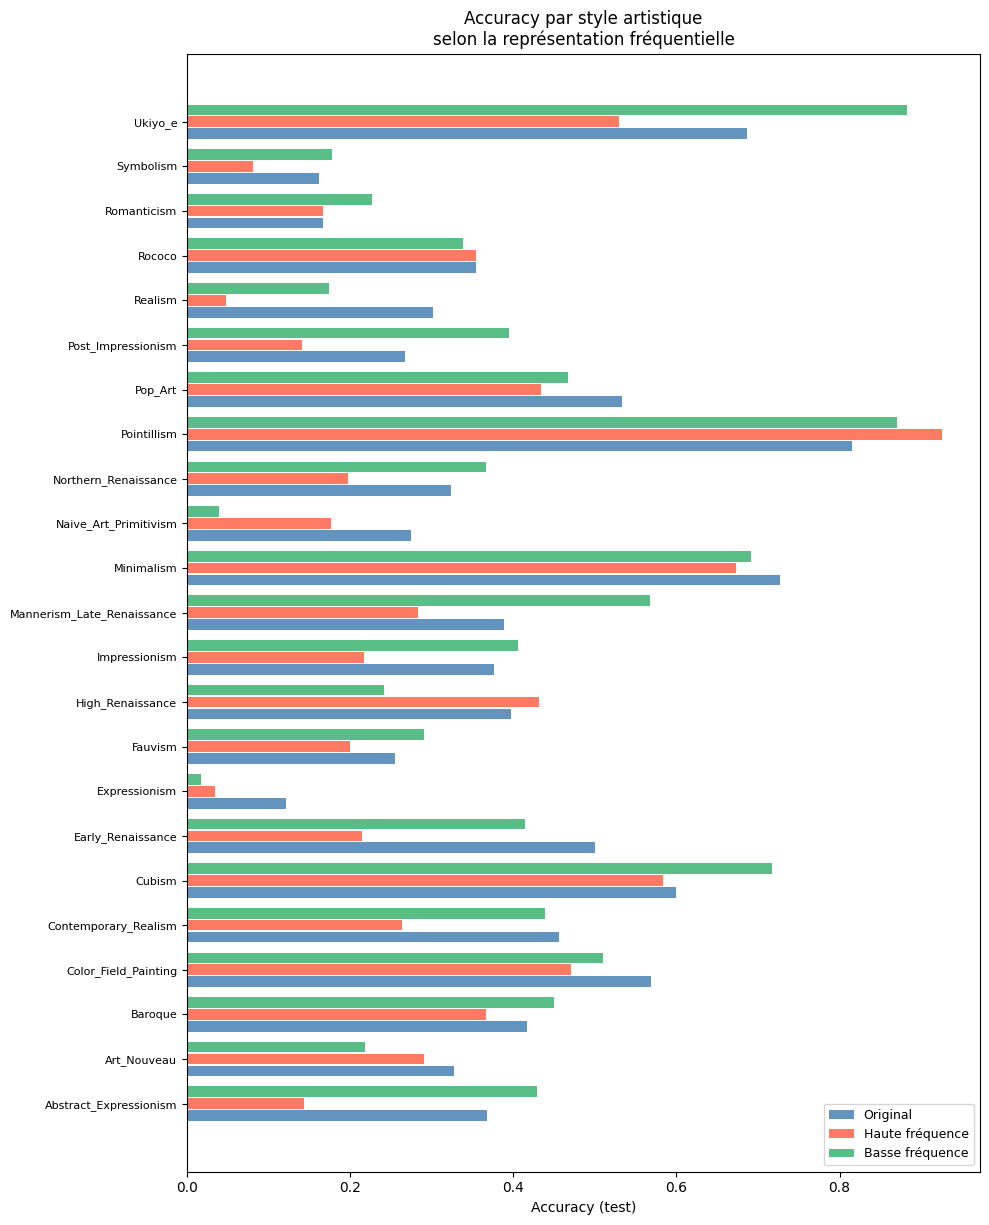

In [ ]:
plot_style_accuracy_comparison(
    {
        'Original'        : per_class_orig,
        'Haute fréquence' : per_class_hf,
        'Basse fréquence' : per_class_lf,
    },
    class_names,
    save_path="/content/freq_style_comparison.png"
)

#### Visualisation t-SNE

In [ ]:

val_loader_orig = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=transform_std),
    batch_size=32, shuffle=False)
val_loader_hf = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=high_freq_transform),
    batch_size=32, shuffle=False)
val_loader_lf = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=low_freq_transform),
    batch_size=32, shuffle=False)
val_loader_mb_tsne = DataLoader(
    ArtDatasetMultiBranch(df_val, IMAGE_ROOT_VAL,
        transform_orig=transform_std,
        transform_hf=high_freq_transform,
        transform_lf=low_freq_transform),
    batch_size=32, shuffle=False)

In [ ]:
from src.dataset_dl import ArtDataset

val_loader_orig_tsne = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=transform_std),
    batch_size=32, shuffle=False, num_workers=0)

import time
start = time.time()
emb_orig, labels_tsne = extract_embeddings(model_orig, val_loader_orig_tsne, device)
print(f"Temps : {time.time()-start:.1f}s")
print(f"Shape : {emb_orig.shape}")

  Batch 0/43
  Batch 10/43
  Batch 20/43
  Batch 30/43
  Batch 40/43
Temps : 562.5s
Shape : (1373, 512)


In [ ]:

val_loader_orig = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=transform_std),
    batch_size=32, shuffle=False, num_workers=0)
val_loader_hf = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=high_freq_transform),
    batch_size=32, shuffle=False, num_workers=0)
val_loader_lf = DataLoader(
    ArtDataset(df_val, IMAGE_ROOT_VAL, transform=low_freq_transform),
    batch_size=32, shuffle=False, num_workers=0)
val_loader_mb_tsne = DataLoader(
    ArtDatasetMultiBranch(df_val, IMAGE_ROOT_VAL,
        transform_orig=transform_std,
        transform_hf=high_freq_transform,
        transform_lf=low_freq_transform),
    batch_size=32, shuffle=False, num_workers=0)


Extraction + t-SNE original...
  Batch 0/43
  Batch 10/43
  Batch 20/43
  Batch 30/43
  Batch 40/43
  PCA...
  t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


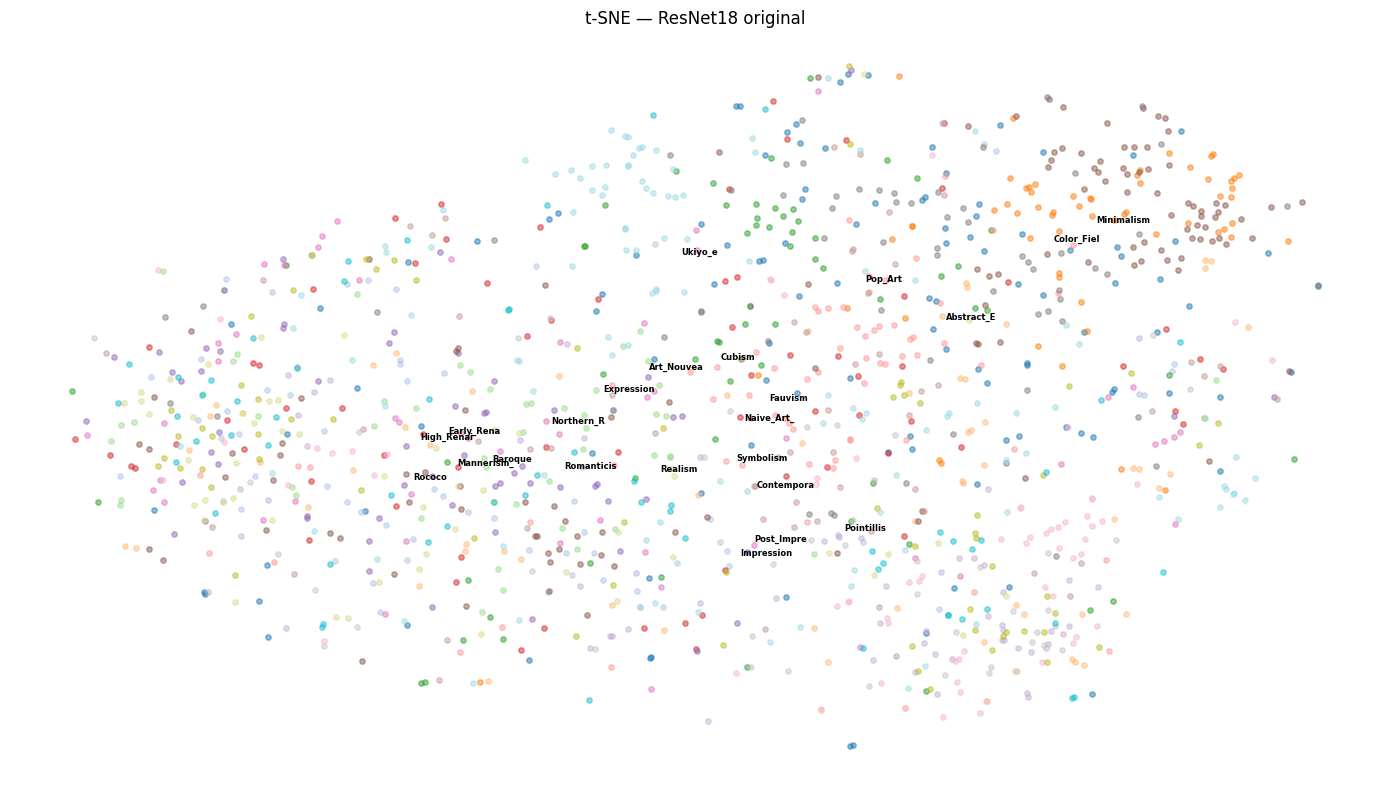

Original sauvegardé
Extraction + t-SNE haute fréquence...
  Batch 0/43
  Batch 10/43
  Batch 20/43
  Batch 30/43
  Batch 40/43
  PCA...
  t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


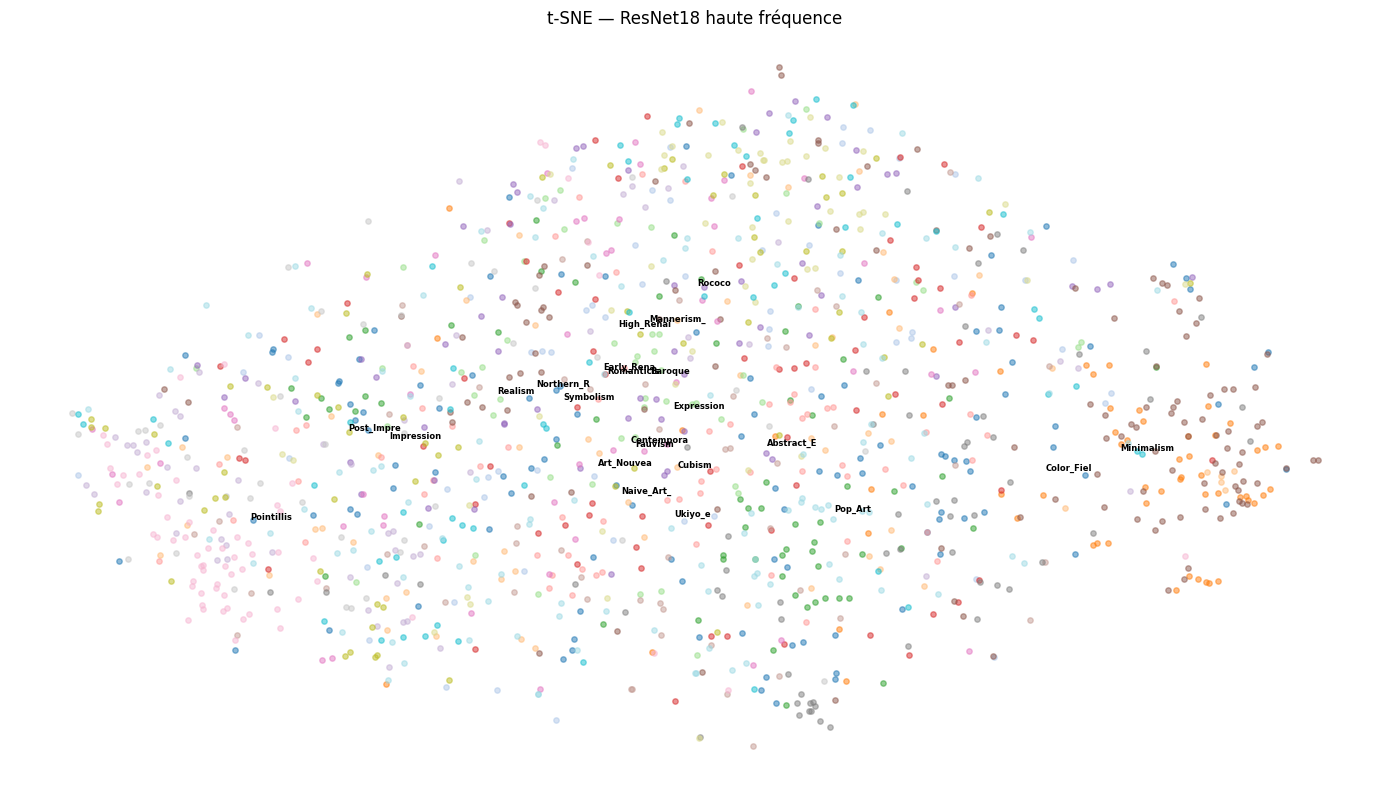

hf sauvegardé
Extraction + t-SNE basse fréquence...
  Batch 0/43
  Batch 10/43
  Batch 20/43
  Batch 30/43
  Batch 40/43
  PCA...
  t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


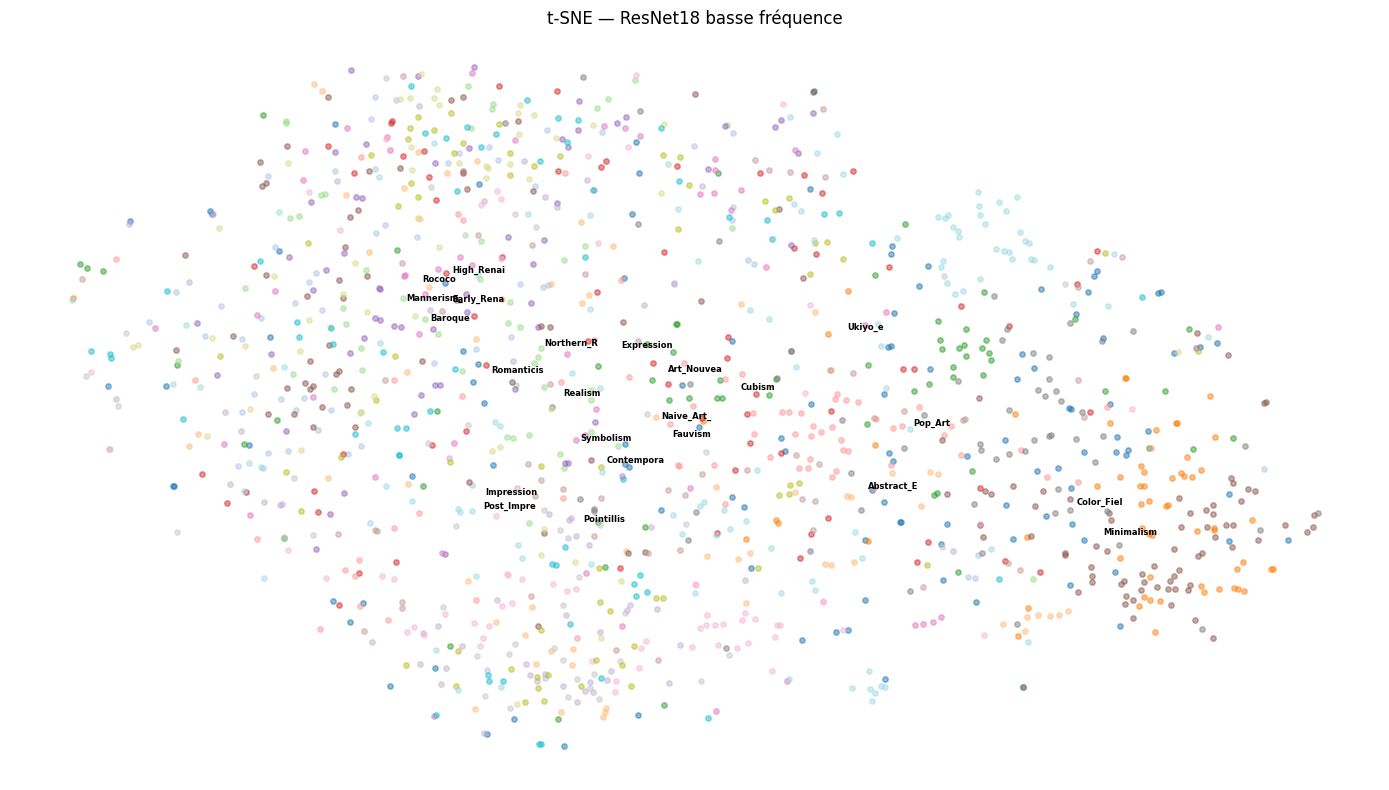

lf sauvegardé
Extraction + t-SNE multi-branches...
  PCA...
  t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


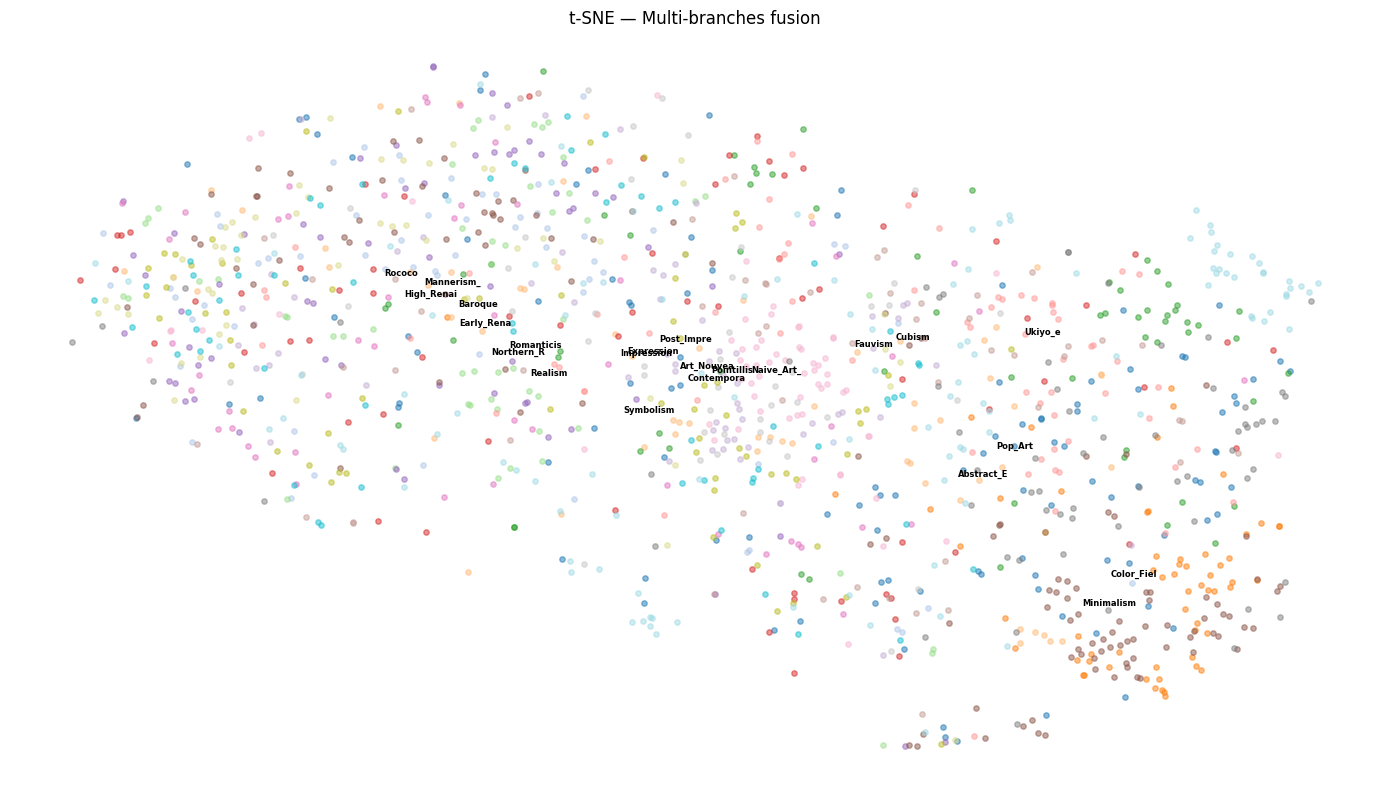

mb sauvegardé


In [ ]:
class_names = sorted(df_test["style_name"].unique())
print("Extraction + t-SNE original...")
emb_orig, labels_tsne = extract_embeddings(model_orig, val_loader_orig, device)
plot_tsne(emb_orig, labels_tsne, class_names, "ResNet18 original",
          save_path="/content/drive/MyDrive/DeepLearning/tsne_original.png")
print("Original sauvegardé")
del emb_orig

print("Extraction + t-SNE haute fréquence...")
emb_hf, _ = extract_embeddings(model_hf, val_loader_hf, device)
plot_tsne(emb_hf, labels_tsne, class_names, "ResNet18 haute fréquence",
          save_path="/content/drive/MyDrive/DeepLearning/tsne_hf.png")
print("hf sauvegardé")
del emb_hf

print("Extraction + t-SNE basse fréquence...")
emb_lf, _ = extract_embeddings(model_lf, val_loader_lf, device)
plot_tsne(emb_lf, labels_tsne, class_names, "ResNet18 basse fréquence",
          save_path="/content/drive/MyDrive/DeepLearning/tsne_lf.png")
print("lf sauvegardé")
del emb_lf

print("Extraction + t-SNE multi-branches...")
emb_mb, _ = extract_embeddings_multibranch(model_mb, val_loader_mb_tsne, device)
plot_tsne(emb_mb, labels_tsne, class_names, "Multi-branches fusion",
          save_path="/content/drive/MyDrive/DeepLearning/tsne_mb.png")
print("mb sauvegardé")
del emb_mb
